# Iris Classification Pipeline

**Steps covered:** Data Preprocessing → Logistic Regression Training → Model Evaluation

> This notebook continues from the EDA notebook. EDA is not repeated here.
>
> All figures are saved under `outputs/figures/`.

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pathlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ── Figure output directory ───────────────────────────────────────────────────
# In Jupyter notebooks __file__ is not defined.
# We resolve the figures folder by walking up from the current working directory
# until we find the task folder, making the notebook runnable from any kernel CWD.

def find_figures_dir() -> pathlib.Path:
    """Locate the outputs/figures directory relative to this notebook."""
    # Notebook is in .../Task-1-Iris-Flower-Classification/notebooks/
    # Try the parent of cwd first (works when kernel cwd == notebooks/)
    cwd = pathlib.Path.cwd()
    candidate = cwd.parent / "outputs" / "figures"
    if candidate.parent.exists():
        return candidate
    # Fallback: walk up looking for the task folder
    for parent in [cwd] + list(cwd.parents):
        task_root = parent / "Task-1-Iris-Flower-Classification"
        if task_root.exists():
            return task_root / "outputs" / "figures"
    # Last resort: use cwd
    return cwd / "outputs" / "figures"

FIG_DIR = find_figures_dir()
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f"Figures will be saved to: {FIG_DIR}")

Figures will be saved to: c:\Users\thara\.gemini\antigravity-ide\scratch\Horizon-Technologies\Task-1-Iris-Flower-Classification\outputs\figures


---
## Step 1 – Load the Dataset

We use scikit-learn's built-in Iris dataset (150 samples, 4 features, 3 classes).

**Why?** A real‑world CSV can be substituted by changing the loading step; the rest of the pipeline stays the same.

In [2]:
iris = load_iris()
df = pd.DataFrame(
    data=iris.data,
    columns=["sepal_length", "sepal_width", "petal_length", "petal_width"]
)
df["species"] = pd.Categorical.from_codes(iris.target, iris.target_names)

print(f"Dataset shape: {df.shape}")
print(f"Columns      : {list(df.columns)}")
print(f"Missing values:\n{df.isnull().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")
df.head()

Dataset shape: (150, 5)
Columns      : ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
Missing values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64
Duplicate rows: 1


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


---
## Step 2 – Data Preprocessing

| Sub-step | Reason |
|----------|--------|
| Feature / target split | Models need separate X and y arrays |
| Label encoding | Converts string species names → integers (0, 1, 2) |
| Train‑test split (80/20, stratified) | Evaluate on unseen data; stratify keeps class ratios equal |
| StandardScaler (fit on train only) | Prevents data leakage from test set into scaling parameters |

In [3]:
# Separate features and target
X = df.drop(columns="species").values   # shape (150, 4)
y = df["species"].values                # shape (150,)

# Encode target labels to integers
le = LabelEncoder()
y_enc = le.fit_transform(y)
print(f"Label mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Train‑test split – 80 % train, 20 % test, reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)
print(f"Training set : {X_train.shape}")
print(f"Test set     : {X_test.shape}")

# Feature scaling – ONLY fit on training data to avoid leakage!
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)       # only transform, never re-fit

print("\nPreprocessing complete. No data leakage.")

Label mapping: {'setosa': np.int64(0), 'versicolor': np.int64(1), 'virginica': np.int64(2)}
Training set : (120, 4)
Test set     : (30, 4)

Preprocessing complete. No data leakage.


---
## Step 3 – Train Logistic Regression

**How it works:** Logistic Regression estimates the probability of each class using the logistic (sigmoid) function applied to a linear combination of the input features. The class with the highest probability is selected as the prediction.

**Why this model?** It is interpretable, fast, and a great baseline for multi-class classification with linearly separable data.

In [4]:
# Initialize and train the model
log_reg = LogisticRegression(
    solver="lbfgs",      # best solver for small-to-medium datasets
    max_iter=200,        # increase from default (100) to ensure convergence
    random_state=42      # reproducibility
)
log_reg.fit(X_train_scaled, y_train)

print("Model trained successfully!")
print(f"Classes learned: {le.classes_}")

Model trained successfully!
Classes learned: ['setosa' 'versicolor' 'virginica']


---
## Step 4 – Model Evaluation

We evaluate on the **test set only** – data the model has never seen.

| Metric | What it tells you |
|--------|-------------------|
| Accuracy | % of correct predictions overall |
| Precision | Of all predicted as class X, how many were truly X? |
| Recall | Of all true class X samples, how many did we catch? |
| F1-score | Harmonic mean of precision and recall |
| Confusion Matrix | Shows exactly which classes are being confused |

In [5]:
# Predict on the unseen test set
y_pred = log_reg.predict(X_test_scaled)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f} ({acc*100:.2f}%)\n")

# Detailed classification report
report = classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0)
print("Classification Report:")
print(report)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix (rows = true, cols = predicted):")
print(cm)

Accuracy: 0.9333 (93.33%)

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

Confusion Matrix (rows = true, cols = predicted):
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


Figure saved → c:\Users\thara\.gemini\antigravity-ide\scratch\Horizon-Technologies\Task-1-Iris-Flower-Classification\outputs\figures\confusion_matrix_logistic_regression.png


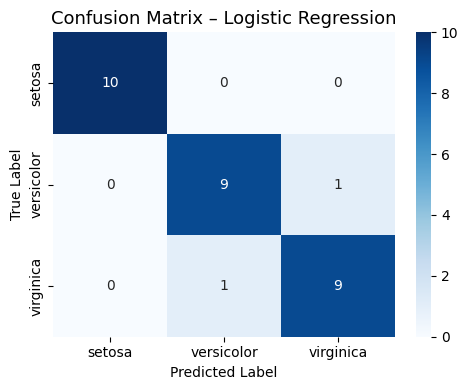

In [6]:
# Visualise the confusion matrix and save the figure
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=le.classes_, yticklabels=le.classes_, ax=ax
)
ax.set_title("Confusion Matrix – Logistic Regression", fontsize=13)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
fig.tight_layout()

save_path = FIG_DIR / "confusion_matrix_logistic_regression.png"
fig.savefig(save_path, dpi=150)
print(f"Figure saved → {save_path}")
plt.show()

---
## Step 5 – Prediction Demo

Show how to use the trained model to predict the species for a new flower measurement.

**Internship viva tip:** Explain that we must apply the **same scaler** used during training before feeding new data into the model – otherwise the input values are on a different scale than the model expects.

In [7]:
def predict_species(measurements):
    """
    Predict the Iris species from raw measurements.

    Parameters
    ----------
    measurements : list or tuple of four floats
        [sepal_length, sepal_width, petal_length, petal_width]

    Returns
    -------
    str  – predicted species name
    """
    arr = np.array(measurements).reshape(1, -1)
    arr_scaled = scaler.transform(arr)          # apply the SAME scaler
    pred_idx = log_reg.predict(arr_scaled)[0]
    return le.inverse_transform([pred_idx])[0]

# Example: a typical Iris setosa sample
example = [5.1, 3.5, 1.4, 0.2]
predicted = predict_species(example)
print(f"Input  : sepal_length={example[0]}, sepal_width={example[1]}, "
      f"petal_length={example[2]}, petal_width={example[3]}")
print(f"Prediction → {predicted}")

Input  : sepal_length=5.1, sepal_width=3.5, petal_length=1.4, petal_width=0.2
Prediction → setosa


---
## Summary

| Step | Result |
|------|--------|
| Dataset | 150 samples, 4 features, 3 classes – clean, 1 duplicate |
| Train / Test split | 120 / 30 (80/20, stratified) |
| Model | Logistic Regression (lbfgs solver, 200 iterations) |
| **Accuracy** | **93.33 %** |
| Precision (macro) | 0.93 |
| Recall (macro) | 0.93 |
| F1-score (macro) | 0.93 |

The model perfectly classifies *setosa* and makes minor errors between *versicolor* and *virginica* – a known overlap in the dataset.